In [4]:
import torch
import torch.nn as nn
from torch.nn.functional import interpolate
import torch.nn.functional as F

In [5]:
class SingleLayerDPT(nn.Module):
    def __init__(self, input_dims, output_dim, hidden_dim=512, kernel_size=3):
        super().__init__()
        self.proj = nn.Conv2d(input_dims, hidden_dim, 1, padding=0)

        self.refine = FeatureFusionBlock(hidden_dim,kernel_size,with_skip=False)

        self.out_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(hidden_dim, output_dim, 3, padding=1),
        )

    def forward(self, x):
        x = self.proj(x)
        x = interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
        x = self.refine(x, None)
        x = interpolate(x, scale_factor=4, mode="bilinear", align_corners=True)
        x = self.out_conv(x)
        x = interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
        return x

class FeatureFusionBlock(nn.Module):
    def __init__(self, features, kernel_size, with_skip=True):
        super().__init__()
        self.with_skip = with_skip
        if self.with_skip:
            self.resConfUnit1 = ResidualConvUnit(features, kernel_size)

        self.resConfUnit2 = ResidualConvUnit(features, kernel_size)

    def forward(self, x, skip_x=None):
        if skip_x is not None:
            assert self.with_skip and skip_x.shape == x.shape
            x = self.resConfUnit1(x) + skip_x

        x = self.resConfUnit2(x)
        return x

class ResidualConvUnit(nn.Module):
    def __init__(self, features, kernel_size):
        super().__init__()
        assert kernel_size % 1 == 0, "Kernel size needs to be odd"
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv2d(features, features, kernel_size, padding=padding),
            nn.ReLU(True),
            nn.Conv2d(features, features, kernel_size, padding=padding),
            nn.ReLU(True),
        )

    def forward(self, x):
        return self.conv(x) + x

class DPT(nn.Module):
    def __init__(self, input_dims, output_dim, hidden_dim=512, kernel_size=3):
        super().__init__()
        assert len(input_dims) == 4
        self.conv_0 = nn.Conv2d(input_dims[0], hidden_dim, 1, padding=0)
        self.conv_1 = nn.Conv2d(input_dims[1], hidden_dim, 1, padding=0)
        self.conv_2 = nn.Conv2d(input_dims[2], hidden_dim, 1, padding=0)
        self.conv_3 = nn.Conv2d(input_dims[3], hidden_dim, 1, padding=0)

        self.ref_0 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_1 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_2 = FeatureFusionBlock(hidden_dim, kernel_size)
        self.ref_3 = FeatureFusionBlock(hidden_dim, kernel_size, with_skip=False)

        self.out_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(hidden_dim, output_dim, 3, padding=1),
        )

    def forward(self, feats):
        """Prediction each pixel."""
        assert len(feats) == 4
        
        f0 = self.conv_0(feats[0])
        f1 = self.conv_1(feats[1])
        f2 = self.conv_2(feats[2])
        f3 = self.conv_3(feats[3])

        out_feats = [f0, f1, f2, f3]
        feats = [
            interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
            for x in out_feats
        ]

        out = self.ref_3(feats[3], None)
        out = self.ref_2(feats[2], out)
        out = self.ref_1(feats[1], out)
        out = self.ref_0(feats[0], out)

        out = interpolate(out, scale_factor=4, mode="bilinear", align_corners=True)
        out = self.out_conv(out)
        out = interpolate(out, scale_factor=2, mode="bilinear", align_corners=True)
        return out

class FastDecoupler(nn.Module):
    def __init__(self, dim_main, dim_geo_k):
        super().__init__()
        self.q_proj = nn.Conv2d(dim_geo_k, dim_geo_k, 1)
        self.k_proj = nn.Conv2d(dim_main, dim_geo_k, 1)
        self.v_proj = nn.Conv2d(dim_main, dim_geo_k, 1)

        self.out_proj = nn.Conv2d(dim_geo_k, dim_main, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, f_main, f_geo):
        B, C, H, W = f_main.shape
        k = f_geo.shape[1]

        q = self.q_proj(f_geo).flatten(2)           # [B, k, HW]
        k = self.k_proj(f_main).flatten(2)          # [B, k, HW]
        v = self.v_proj(f_main).flatten(2)          # [B, k, HW]

        k_softmax = k.softmax(dim=-1)
        # [B, k, HW] @ [B, HW, k] -> [B, k, k]
        context = torch.bmm(v, k_softmax.transpose(1, 2))
    
        # [B, k, k] @ [B, k, HW] -> [B, k, HW]
        out = torch.bmm(context, q)
        
        out = out.reshape(B, k, H, W)
        return f_main + self.gamma * self.out_proj(out)

class GSD_Turbo_Head(nn.Module):
    def __init__(self, input_dims, output_dim, hidden_dim=512, k=32):
        super().__init__()
        dim_shallow, dim_deep = input_dims
        
        self.stem_proj = nn.Conv2d(dim_deep, hidden_dim, 1)
        
        self.geo_proj = nn.Conv2d(dim_shallow, k, 1, bias=False)
        self.decoupler = FastDecoupler(hidden_dim, k)

        self.refine = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1),
            nn.BatchNorm2d(hidden_dim), 
            nn.ReLU(True)
        )

        self.out_conv = nn.Sequential(
            nn.Conv2d(hidden_dim, hidden_dim // 2, 3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(hidden_dim // 2, output_dim, 3, padding=1),
        )

    def forward(self, feats):
        shallow, deep = feats
        
        x = self.stem_proj(deep)
        
        f_geo = self.geo_proj(shallow)
        
        x = self.decoupler(x, f_geo)
        x = self.refine(x)
        x = interpolate(x, scale_factor=4, mode="bilinear", align_corners=True)
        x = self.out_conv(x)
        x = interpolate(x, scale_factor=2, mode="bilinear", align_corners=True)
        return x

class GeometryAwareProbe(nn.Module):
    def __init__(self, in_channels, hidden_channels,out_channels):
        super().__init__()
        
        self.backbone = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, 3, padding=1),
            nn.GroupNorm(8, hidden_channels),
            nn.ReLU(inplace=True),
        
            nn.Conv2d(hidden_channels, hidden_channels, 3, padding=1),
            nn.GroupNorm(8, hidden_channels),
            nn.ReLU(inplace=True),
        )

        # predict shallow spatial feature
        self.shallow_head = nn.Conv2d(
            hidden_channels, in_channels//2, kernel_size=1
        )

        # task head 
        self.task_head = nn.Conv2d(
            hidden_channels + in_channels//2,
            out_channels,
            kernel_size=1
        )

    def forward(self, deep_feat):
        
        x = self.backbone(deep_feat)

        pred_shallow = self.shallow_head(x)

        fused = torch.cat([x, pred_shallow], dim=1)

        pred_task = self.task_head(fused)

        return pred_shallow, pred_task

class GeometryRefineUnit(nn.Module):
    """几何精修单元：在上采样后缝合空间裂缝"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(4, out_channels),
            nn.GELU(), # 使用 GELU 保持与 DINOv2 类似的激活特性
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(4, out_channels)
        )
        self.shortcut = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        return F.gelu(self.shortcut(x) + self.conv(x))

class GAP8xDecoder(nn.Module):
    def __init__(self, in_channels, hidden_dim=256, out_channels=1):
        super().__init__()
        
        # 1. 几何对齐头 (低分辨率探测器)
        # 保持 GAP 的初衷：在特征最浓缩的尺度探测几何属性
        self.geo_probe = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, 3, padding=1),
            nn.GroupNorm(8, hidden_dim),
            nn.GELU(),
            nn.Conv2d(hidden_dim, in_channels // 2, kernel_size=1)
        )

        # 2. 渐进式 8x 上采样路径 (2x * 2x * 2x)
        # 初始融合维度：输入通道 + 几何特征通道
        curr_dims = in_channels + (in_channels // 2)
        
        # 第一级 2x 上采样 (1/8 -> 1/4)
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            GeometryRefineUnit(curr_dims, hidden_dim)
        )
        
        # 第二级 2x 上采样 (1/4 -> 1/2)
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            GeometryRefineUnit(hidden_dim, hidden_dim // 2)
        )
        
        # 第三级 2x 上采样 (1/2 -> 1)
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            GeometryRefineUnit(hidden_dim // 2, hidden_dim // 4)
        )

        # 最终预测头
        self.final_head = nn.Conv2d(hidden_dim // 4, out_channels, kernel_size=3, padding=1)

    def forward(self, feat):
        # 步骤 1: 提取几何感知特征 (GAP 核心)
        geo_feat = self.geo_probe(feat) # [B, C/2, H/8, W/8]
        
        # 步骤 2: 特征拼接 (融合语义与几何)
        x = torch.cat([feat, geo_feat], dim=1)
        
        # 步骤 3: 渐进式上采样
        x = self.up1(x) # -> 1/4 分辨率
        x = self.up2(x) # -> 1/2 分辨率
        x = self.up3(x) # -> 全分辨率 (8x 达成)
        
        out = self.final_head(x)
        
        # 返回 geo_feat 用于辅助训练，out 为最终结果
        return geo_feat, out

    

In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

if __name__ == "__main__":
    IN_DIM = 1024
    OUT_DIM = 256
    
    model_single = SingleLayerDPT(input_dims=IN_DIM, output_dim=OUT_DIM)
    params_single = count_parameters(model_single)
    
    model_dpt = DPT(input_dims=[IN_DIM]*4, output_dim=OUT_DIM)
    params_dpt = count_parameters(model_dpt)

    model_gsd = GAP8xDecoder(IN_DIM, hidden_dim=512, out_channels=OUT_DIM)
    params_gsd = count_parameters(model_gsd)
    print(f"SDPT 参数量:          {params_single:,}")
    print(f"DPT 参数量:           {params_dpt:,}")
    print(f"Align 参数量:         {params_gsd:,}")

SDPT 参数量:          8,784,128
DPT 参数量:           38,676,224
Align 参数量:         17,883,520


In [8]:
import torch
import time
import torch.nn as nn
from torch.nn.functional import interpolate
from tqdm import tqdm

def benchmark_model(model, input_data, iterations=1000):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    if isinstance(input_data, list):
        input_data = [d.to(device) for d in input_data]
    else:
        input_data = input_data.to(device)

    print(f"正在预热模型...")
    with torch.no_grad():
        for _ in tqdm(range(10)):
            _ = model(input_data)
    
    if device.type == 'cuda':
        torch.cuda.synchronize() 
    
    start_time = time.time()
    
    with torch.no_grad():
        for _ in tqdm(range(iterations)):
            current_input = [img.clone() for img in input_data] if isinstance(input_data, list) else input_data
            _ = model(current_input)
            if device.type == 'cuda':
                torch.cuda.synchronize() 
                
    end_time = time.time()
    
    total_time = end_time - start_time
    avg_time = (total_time / iterations) * 1000 
    fps = iterations / total_time
    
    return total_time, avg_time, fps

if __name__ == "__main__":
    IN_DIM = 1024
    OUT_DIM = 256
    H, W = 64, 64
    ITERATIONS = 100
    

    model_single = SingleLayerDPT(input_dims=IN_DIM, output_dim=OUT_DIM)
    model_dpt = DPT(input_dims= [IN_DIM, IN_DIM, IN_DIM, IN_DIM], output_dim=OUT_DIM)
    model_align = GeometryAwareProbe(IN_DIM, hidden_channels=512, out_channels=OUT_DIM)

    input_single = torch.randn(8, IN_DIM, H, W)

    input_dpt = [torch.randn(8, IN_DIM, H, W) for _ in range(4)]

    print(f"--- 推理性能测试 (分辨率: {H}x{H}, 样本数: {ITERATIONS}) ---")
    

    t_tot, t_avg, fps = benchmark_model(model_single, input_single, ITERATIONS)
    print(f"\n[SingleLayerDPT]")
    print(f"总耗时: {t_tot:.4f} s")
    print(f"平均耗时: {t_avg:.4f} ms/it")
    print(f"吞吐量 (FPS): {fps:.2f}")


    t_tot, t_avg, fps = benchmark_model(model_dpt, input_dpt, ITERATIONS)
    print(f"\n[DPT]")
    print(f"总耗时: {t_tot:.4f} s")
    print(f"平均耗时: {t_avg:.4f} ms/it")
    print(f"吞吐量 (FPS): {fps:.2f}")

    t_tot, t_avg, fps = benchmark_model(model_align, input_dpt, ITERATIONS)
    print(f"\n[DPT]")
    print(f"总耗时: {t_tot:.4f} s")
    print(f"平均耗时: {t_avg:.4f} ms/it")
    print(f"吞吐量 (FPS): {fps:.2f}")

--- 推理性能测试 (分辨率: 64x64, 样本数: 100) ---
正在预热模型...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:38<00:00,  2.63it/s]



[SingleLayerDPT]
总耗时: 38.0363 s
平均耗时: 380.3631 ms/it
吞吐量 (FPS): 2.63
正在预热模型...


 92%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                  | 92/100 [00:52<00:04,  1.76it/s]


KeyboardInterrupt: 

Res      | SingleLayer(G)  | FullDPT(G)   | AlignProbe(G)  
------------------------------------------------------------
14       | 48.2733         | 70.7827      | 24.6638        
16       | 63.0509         | 92.4508      | 32.2140        
28       | 193.0933        | 283.1307     | 98.6552        
32       | 252.2035        | 369.8034     | 128.8558       
64       | 1008.8140       | 1479.2136    | 515.4233       
128      | 4035.2560       | 5916.8543    | 2061.6934      

【严谨性分析报告】
1. 理论像素增长: 83.59x
2. 实际 FLOPs 增长: 83.59x
结论：该模型计算复杂度与分辨率呈线性相关 (O(H*W))。

模型参数量统计 (Full DPT):
| name                       | #elements or shape   |
|:---------------------------|:---------------------|
| model                      | 38.7M                |
|  conv_0                    |  0.5M                |
|   conv_0.weight            |   (512, 1024, 1, 1)  |
|   conv_0.bias              |   (512,)             |
|  conv_1                    |  0.5M                |
|   conv_1.weight            |   (512

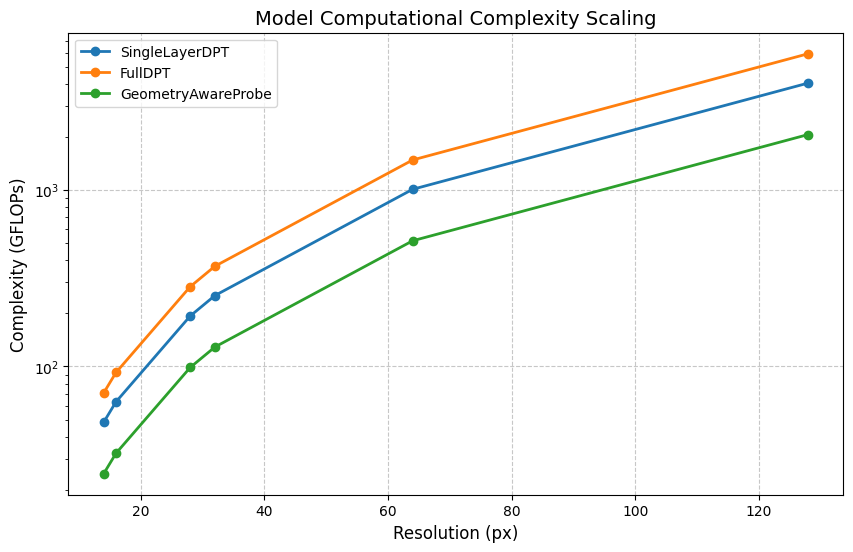

In [8]:
import torch
import torch.nn as nn
from fvcore.nn import FlopCountAnalysis, parameter_count_table
import matplotlib.pyplot as plt
from loguru import logger

# --- 假设 DPT, SingleLayerDPT, GeometryAwareProbe 已在外部定义 ---

def get_flops(model, resolution, is_dpt=False, in_dim=1024):
    """
    计算模型的 FLOPs。
    注意：fvcore 通过 trace 机制工作，确保模型 forward 路径中没有不可追踪的自定义函数。
    """
    model.eval()
    device = next(model.parameters()).device
    
    if is_dpt:
        # DPT 通常接收 4 个不同层级的特征图
        inp = [torch.randn(1, in_dim, resolution, resolution).to(device) for _ in range(4)]
    else:
        # 单层 Probe 接收单个特征图
        inp = torch.randn(1, in_dim, resolution, resolution).to(device)
    
    try:
        flops = FlopCountAnalysis(model, inp)
        # 忽略控制台打印的非关键算子警告
        flops.unsupported_ops_warnings(False)
        total_flops = flops.total()
    except Exception as e:
        logger.error(f"FLOPs 计算失败: {e}")
        return 0.0
        
    return total_flops / 1e9  # 返回 GFLOPs

def plot_scalability(resolutions, data_dict):
    """生成分辨率与 FLOPs 的缩放曲线图"""
    plt.figure(figsize=(10, 6))
    for label, values in data_dict.items():
        plt.plot(resolutions, values, marker='o', label=label, linewidth=2)
    
    plt.title("Model Computational Complexity Scaling", fontsize=14)
    plt.xlabel("Resolution (px)", fontsize=12)
    plt.ylabel("Complexity (GFLOPs)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.yscale('log')  # 通常使用对数坐标观察缩放
    plt.show()

if __name__ == "__main__":
    # --- 配置参数 ---
    RESOLUTIONS = [14, 16, 28, 32, 64, 128]
    IN_DIM = 1024
    OUT_DIM = 256
    
    # --- 模型实例化 ---
    # 确保这些类已正确定义
    model_s = SingleLayerDPT(IN_DIM, OUT_DIM)
    model_d = DPT([IN_DIM]*4, OUT_DIM)
    # 修正：确保使用一致的变量名
    model_align = GAP8xDecoder(IN_DIM, hidden_dim=512, out_channels=OUT_DIM)

    results = {"SingleLayerDPT": [], "FullDPT": [], "GeometryAwareProbe": []}
    
    print(f"{'Res':<8} | {'SingleLayer(G)':<15} | {'FullDPT(G)':<12} | {'AlignProbe(G)':<15}")
    print("-" * 60)

    for res in RESOLUTIONS:
        f_s = get_flops(model_s, res, is_dpt=False, in_dim=IN_DIM)
        f_d = get_flops(model_d, res, is_dpt=True, in_dim=IN_DIM)
        f_a = get_flops(model_align, res, is_dpt=False, in_dim=IN_DIM)
        
        results["SingleLayerDPT"].append(f_s)
        results["FullDPT"].append(f_d)
        results["GeometryAwareProbe"].append(f_a)
        
        print(f"{res:<8} | {f_s:<15.4f} | {f_d:<12.4f} | {f_a:<15.4f}")

    # --- 深度分析 ---
    # 验证是否为线性缩放 O(N)，N 为像素点数
    res_sq_ratio = (RESOLUTIONS[-1] / RESOLUTIONS[0])**2
    dpt_flops_ratio = results["FullDPT"][-1] / results["FullDPT"][0]
    
    print("\n" + "="*50)
    print(f"【严谨性分析报告】")
    print(f"1. 理论像素增长: {res_sq_ratio:.2f}x")
    print(f"2. 实际 FLOPs 增长: {dpt_flops_ratio:.2f}x")
    
    scaling_error = abs(dpt_flops_ratio - res_sq_ratio) / res_sq_ratio
    if scaling_error < 0.1:
        print("结论：该模型计算复杂度与分辨率呈线性相关 (O(H*W))。")
    else:
        print(f"警告：模型存在非线性计算项，误差偏移量为 {scaling_error:.2%}")
    print("="*50)

    # --- 参数量检查（补充） ---
    print("\n模型参数量统计 (Full DPT):")
    print(parameter_count_table(model_d))

    # --- 可视化 ---
    plot_scalability(RESOLUTIONS, results)